Utilizzando il dataset Diabetes, replicare l'esercitazione pratica.
- Plottare gli istogrammi di tutte le feature e target
- Effettuare lo split con dimensioni del test set del 20% dell'intero dataset
- Effettuare la standarizzazione sui set train e test
- Allenare un regressore lineare e confrontare MSE e R2 della predizioni sul set di training e testing.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

Utilizzando il dataset Diabetes

In [2]:
data=load_diabetes()
X=pd.DataFrame(data.data,columns=data.feature_names)
y=pd.Series(data.target, name="target")

df=X.copy()
df['target']=y
display(df)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


- Plottare gli istogrammi di tutte le feature e target

feature

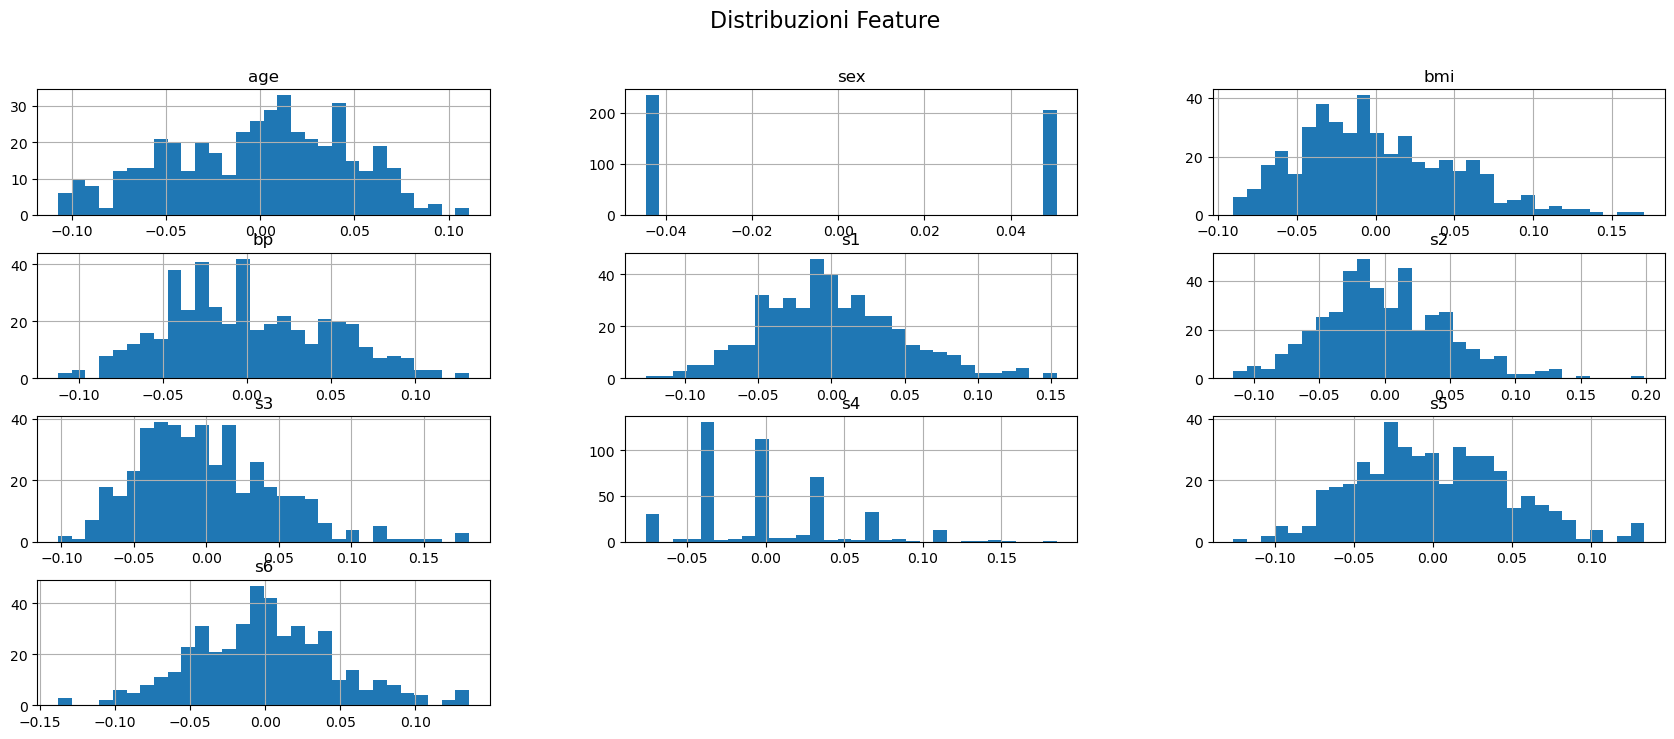

In [3]:
X.hist(bins=30,figsize=(21,8))
plt.suptitle("Distribuzioni Feature",fontsize=16)
plt.show()

target

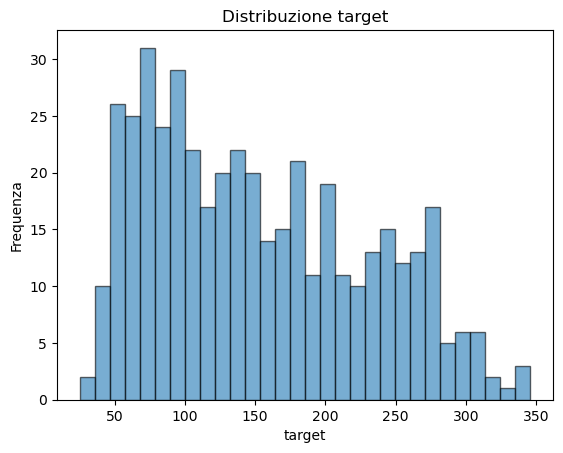

In [5]:
plt.hist(y,bins=30,edgecolor='black',alpha=0.6)
plt.title("Distribuzione target")
plt.xlabel("target")
plt.ylabel("Frequenza")
plt.show()

In [6]:
X_train,X_test, y_train, y_test=train_test_split(X,y,test_size=0.2, random_state=42)
print(f"Training set:\t{X_train.shape}")
print(f"Test set:\t{X_test.shape}")

Training set:	(353, 10)
Test set:	(89, 10)


In [8]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)

In [9]:
model=LinearRegression()
model.fit(X_train_scaled,y_train)

y_pred_traing=model.predict(X_train_scaled)
y_pred_test=model.predict(X_test_scaled)

mse_train=mean_squared_error(y_train,y_pred_traing)
mse_test=mean_squared_error(y_test,y_pred_test)
r2_train=r2_score(y_train,y_pred_traing)
r2_test=r2_score(y_test,y_pred_test)

print(f"MES train:\t{mse_train}\t MES test: {mse_test}")
print(f"R2 train:\t{r2_train}\t R2 test: {r2_test}")

MES train:	2868.549702835577	 MES test: 2972.851534699921
R2 train:	0.5279193863361498	 R2 test: 0.4388889416894727
